# ASSIGNMENT 8

## Building a Variational Autoencoder and Visualising Its Latent Space

**Objective:** Understand how a Variational Autoencoder (VAE) learns a structured latent space using the MNIST dataset.

---


## 1. Introduction

### What is a Variational Autoencoder (VAE)?

A **Variational Autoencoder (VAE)** is a type of generative neural network that learns to compress data (like images) into a compact, continuous representation called a **latent space**, and then reconstruct the original data back from that representation. Unlike a simple autoencoder, a VAE does not map an input to a single fixed point in the latent space. Instead, it maps the input to a *probability distribution* (defined by a mean and a variance), and a point is then *sampled* from this distribution. This probabilistic approach is what allows a VAE to generate new, realistic data by sampling random points from the latent space.

### Difference between a normal Autoencoder and a VAE

| Aspect | Normal Autoencoder | Variational Autoencoder (VAE) |
|---|---|---|
| Latent representation | A single fixed vector per input | A probability distribution (mean, variance) per input |
| Latent space structure | Not necessarily continuous or organized | Continuous and smoothly organized (regularized) |
| Generation of new data | Poor — latent space may have "gaps" | Good — any sampled point decodes to a realistic image |
| Loss function | Only reconstruction loss | Reconstruction loss **+** KL-divergence loss |
| Sampling | Not applicable | Reparameterization trick used to sample latent vectors |

### What is a Latent Space?

A **latent space** is a lower-dimensional, compressed representation of the input data learned by the network. Instead of working with the full 784 pixel values of a 28×28 MNIST image, the encoder compresses each image into just a few numbers that (ideally) capture the most important underlying features of the digit, such as its shape and style.

### Why are we using a 2-Dimensional Latent Space?

We deliberately use a **2D latent space** (instead of a more typical 16D, 32D, or higher) so that we can directly **plot and visualise** it on a simple 2D scatter plot. This lets us see, in a very intuitive way, how the VAE organizes different digit classes into distinct regions/clusters, and how it structures the space continuously between them.

### How Does a VAE Generate New Images?

Once trained, the **decoder** half of the VAE can be used independently. Since the encoder was trained to map images to a smooth, continuous, roughly-Gaussian distribution in latent space (enforced by the KL-divergence loss), we can pick **any** point (even ones never explicitly seen during training) in that 2D space, feed it into the decoder, and it will output a realistic-looking, novel digit image. This is the core idea behind using a VAE as a *generative* model.

---


## 2. Objective

The objective of this experiment is to:

1. Build and train a Variational Autoencoder (VAE) on the MNIST handwritten digit dataset.
2. Compress each 28×28 digit image into a **2-dimensional latent vector** using an encoder network.
3. Reconstruct the original image from this latent vector using a decoder network.
4. Train the network using a combined **reconstruction loss** and **KL-divergence loss**.
5. Visualise the learned 2D latent space as a scatter plot, coloured by digit class (0–9).
6. Generate new, never-before-seen digit images by decoding a grid of points sampled directly from the latent space.
7. Observe and report how well the VAE clusters similar digits together and produces smooth transitions between digit classes.

---


## 3. Dataset

We use the **MNIST Handwritten Digit Dataset**, a standard benchmark dataset in machine learning and computer vision.

| Property | Description |
|---|---|
| Number of classes | 10 (digits 0 through 9) |
| Image size | 28 × 28 pixels, grayscale (1 channel) |
| Pixel value range | 0 to 255 (raw), normalized to 0–1 for training |
| Training samples | 60,000 images |
| Testing samples | 10,000 images |

### Why is MNIST suitable for this experiment?

* It is **small and simple enough** to train a VAE quickly, even on a laptop/Colab CPU/GPU, within ~20 epochs.
* Each image belongs to a clear, well-defined class (digit 0–9), which makes it easy to **colour the latent-space scatter plot by label** and visually inspect clustering.
* The dataset is **clean and well-preprocessed** already, so minimal additional cleaning is required.
* MNIST is a **standard benchmark**, so results can be easily compared against known VAE behaviour described in literature and coursework.

---


## 4. Libraries

We keep the import list minimal — only what is required to build, train, and visualise the VAE.


In [1]:
# ============================================================
# 4. Required Libraries
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 5. Load and Preprocess MNIST

Steps performed below:

1. Load the MNIST dataset using `keras.datasets.mnist`.
2. Normalize pixel values from the range [0, 255] to [0, 1] (helps training stability, and is required since we use a sigmoid output + binary cross-entropy reconstruction loss).
3. Reshape/flatten the 28×28 images into 784-dimensional vectors, since our encoder/decoder use Dense layers.
4. Display a few sample MNIST images (**Figure 1**).


In [2]:
# ============================================================
# 5. Load and Preprocess MNIST
# ============================================================

# Load dataset (train/test split provided by Keras)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Keep original image shape for display purposes
x_train_images = x_train.copy()
x_test_images = x_test.copy()

# Flatten 28x28 images into 784-dimensional vectors for the Dense VAE
image_size = 28 * 28
x_train_flat = x_train.reshape((-1, image_size))
x_test_flat = x_test.reshape((-1, image_size))

print("Training data shape (flattened):", x_train_flat.shape)
print("Testing data shape (flattened):", x_test_flat.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape (flattened): (60000, 784)
Testing data shape (flattened): (10000, 784)
Training labels shape: (60000,)
Testing labels shape: (10000,)


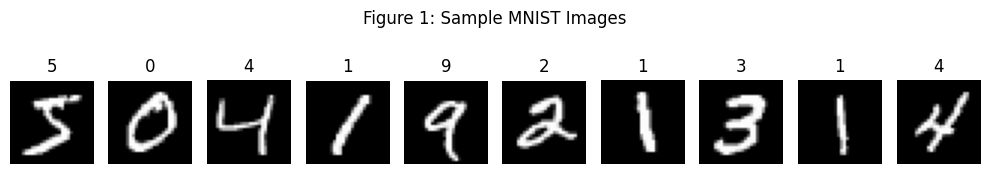

In [3]:
# ------------------------------------------------------------
# Figure 1: Display a few sample MNIST images
# ------------------------------------------------------------
n_samples = 10
plt.figure(figsize=(10, 2))
for i in range(n_samples):
    ax = plt.subplot(1, n_samples, i + 1)
    plt.imshow(x_train_images[i], cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.suptitle("Figure 1: Sample MNIST Images")
plt.tight_layout()
plt.show()


## 6. Build the VAE

The VAE consists of three main parts:

1. **Encoder** — compresses the 784-dimensional input image into two vectors: `z_mean` and `z_log_var`, which parameterize a Gaussian distribution over the 2D latent space.
2. **Sampling layer (Reparameterization Trick)** — draws a latent vector `z` from that distribution in a way that keeps the whole model differentiable:

$$ z = \mu + \exp(0.5 \cdot \log\sigma^2) \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1) $$

   This trick is necessary because directly sampling from a distribution is not a differentiable operation — by instead sampling a fixed noise term `epsilon` and using it inside a deterministic formula, gradients can flow back through `z_mean` and `z_log_var` during backpropagation.

3. **Decoder** — takes a 2-dimensional latent vector `z` and reconstructs a full 784-dimensional (28×28) image from it.

### Architecture summary

| Component | Layers |
|---|---|
| Encoder | Input(784) → Dense(256, relu) → Dense(64, relu) → [z_mean(2), z_log_var(2)] |
| Sampling | z = z_mean + exp(0.5 * z_log_var) * epsilon |
| Decoder | Input(2) → Dense(64, relu) → Dense(256, relu) → Dense(784, sigmoid) |


In [4]:
# ============================================================
# 6.1 Encoder
# ============================================================
latent_dim = 2  # Exactly 2 dimensions, as required for visualisation

encoder_inputs = keras.Input(shape=(image_size,), name="encoder_input")

x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_inputs)
x = layers.Dense(64, activation="relu", name="encoder_dense_2")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 256)       │    200,960 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 64)        │     16,448 │ encoder_dense_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ encoder_dense_2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,668 (850.27 KB)

 Trainable params: 217,668 (850.27 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================================
# 6.2 Sampling Layer (Reparameterization Trick)
# ============================================================
class Sampling(layers.Layer):
    # Samples z from N(z_mean, exp(z_log_var)) using the
    # reparameterization trick: z = z_mean + exp(0.5 * z_log_var) * epsilon

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))  # epsilon ~ N(0, 1)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


sampling_layer = Sampling(name="z_sampling")


In [6]:
# ============================================================
# 6.3 Decoder
# ============================================================
latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")

x = layers.Dense(64, activation="relu", name="decoder_dense_1")(latent_inputs)
x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
decoder_outputs = layers.Dense(image_size, activation="sigmoid", name="decoder_output")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,320 (852.81 KB)

 Trainable params: 218,320 (852.81 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Combining into a Full VAE Model

We wrap the encoder, sampling layer, and decoder into a single custom `keras.Model` subclass. This lets us define a custom `train_step` so we can compute and separately track the **reconstruction loss** and the **KL-divergence loss** during training (needed for Section 9's graph).


In [7]:
# ============================================================
# 6.4 Full VAE Model (custom train_step to track both losses)
# ============================================================
class VAE(keras.Model):
    def __init__(self, encoder, decoder, sampling_layer, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling_layer = sampling_layer

        # Metrics to track loss components across an epoch
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.sampling_layer([z_mean, z_log_var])
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampling_layer([z_mean, z_log_var])
            reconstruction = self.decoder(z)

            # ---- Reconstruction Loss (Binary Cross-Entropy) ----
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=0,
                )
            )
            # Normalize by number of pixels so it is on a comparable scale
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            ) * image_size

            # ---- KL-Divergence Loss ----
            # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder, sampling_layer)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


## 7. Loss Function

The VAE is trained by minimizing the sum of two loss terms:

### 1. Reconstruction Loss

Measures how well the decoder's output image matches the original input image, using **Binary Cross-Entropy**:

$$ \mathcal{L}_{recon} = -\sum_{i=1}^{784} \Big[ x_i \log(\hat{x}_i) + (1 - x_i)\log(1 - \hat{x}_i) \Big] $$

where $x$ is the original (flattened, normalized) image and $\hat{x}$ is the reconstructed image. In simple terms: **this loss penalizes the model when the reconstructed digit looks different from the original digit.**

### 2. KL-Divergence Loss

Measures how much the learned latent distribution $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ diverges from a standard normal distribution $\mathcal{N}(0, 1)$:

$$ \mathcal{L}_{KL} = -0.5 \times \sum_{j=1}^{d} \Big(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \Big) $$

In simple terms: **this loss keeps the latent space "well-behaved"** — it discourages the encoder from spreading out or isolating points arbitrarily far from the origin, forcing the latent distributions of different inputs to overlap smoothly. This is exactly what makes new-image generation possible: since the whole space resembles a standard normal distribution, decoding *any* nearby point produces a realistic image.

### Total VAE Loss

$$ \mathcal{L}_{VAE} = \mathcal{L}_{recon} + \mathcal{L}_{KL} $$

---


## 8. Model Training

We train the VAE for **20 epochs** with a **batch size of 128**, using the Adam optimizer. The custom `train_step` defined above returns the reconstruction loss and KL-divergence loss for every batch; Keras's `History` callback automatically averages these per epoch, which we store for the loss-vs-epoch graph in Section 9.


In [8]:
# ============================================================
# 8. Train the VAE
# ============================================================
EPOCHS = 20
BATCH_SIZE = 128

history = vae.fit(
    x_train_flat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)

# Store the per-epoch loss values for plotting
recon_loss_history = history.history["reconstruction_loss"]
kl_loss_history = history.history["kl_loss"]
total_loss_history = history.history["loss"]

print("Training complete.")
print("Final reconstruction loss:", recon_loss_history[-1])
print("Final KL-divergence loss:", kl_loss_history[-1])
print("Final total loss:", total_loss_history[-1])


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - kl_loss: 5.8432 - loss: 194.3252 - reconstruction_loss: 188.4820
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8652 - loss: 166.6123 - reconstruction_loss: 161.7472
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.2070 - loss: 160.7315 - reconstruction_loss: 155.5245
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4311 - loss: 157.2908 - reconstruction_loss: 151.8597
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.5708 - loss: 155.1773 - reconstruction_loss: 149.6066
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6821 - loss: 153.6514 - reconstruction_loss: 147.9693
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.7427 - loss: 152.3804 - reconstruction_loss: 146.6376
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.8113 - loss: 151.3658 - reconstruction_loss: 145.5546
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/s

## 9. Training Loss Graph

**Figure 2** below plots the Reconstruction Loss and KL-Divergence Loss against Epoch number, tracked separately during training.


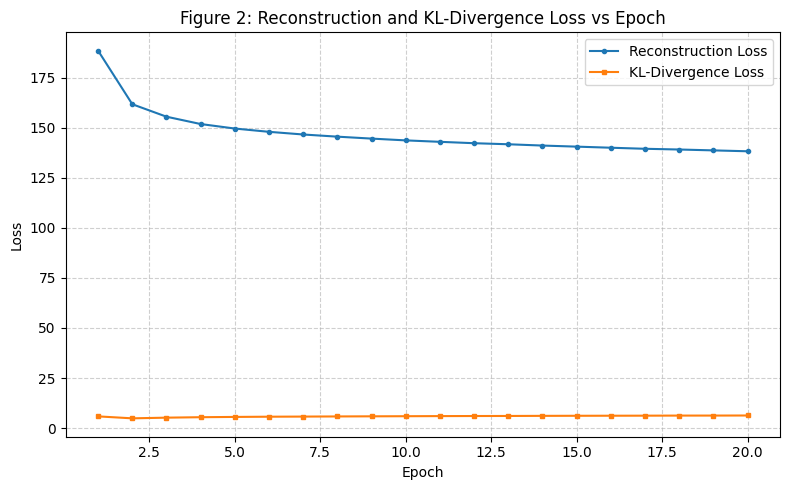

In [9]:
# ============================================================
# Figure 2: Reconstruction Loss and KL-Divergence Loss vs Epoch
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, recon_loss_history, label="Reconstruction Loss", marker="o", markersize=3)
plt.plot(epochs_range, kl_loss_history, label="KL-Divergence Loss", marker="s", markersize=3)
plt.title("Figure 2: Reconstruction and KL-Divergence Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Observations on training losses** *(record the actual pattern seen after running the cells above):*

1. The reconstruction loss should decrease steadily over the 20 epochs as the decoder learns to reproduce input digits more accurately.
2. The KL-divergence loss typically rises briefly in the very first epoch(s), as the encoder initially spreads latent points out, then stabilizes/decreases slightly as the distribution is regularized toward $\mathcal{N}(0,1)$.
3. The total loss (sum of both) should show an overall downward trend, indicating the network is successfully learning both to reconstruct digits and to regularize the latent space.
4. *(Fill in any additional epoch-specific behaviour you observe, e.g. any epoch where losses plateaued or fluctuated, after running the notebook.)*

---


## 10. Visualise the 2D Latent Space

We now pass all **test images** through the trained encoder to obtain their 2-dimensional `z_mean` latent coordinates, and plot them as a scatter plot coloured by digit label (0–9). This is **Figure 3**.


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


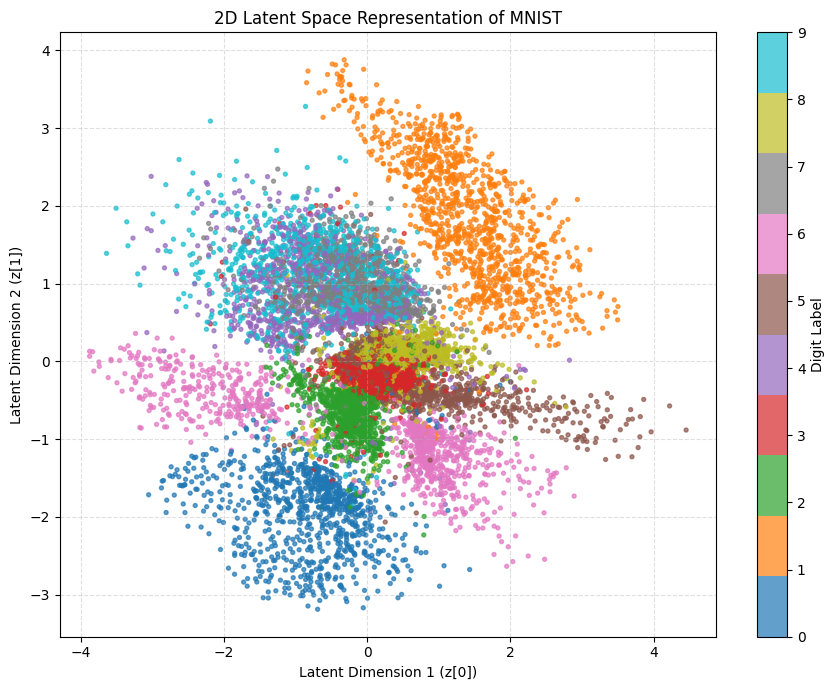

In [10]:
# ============================================================
# Figure 3: 2D Latent Space Scatter Plot (colored by digit label)
# ============================================================
z_mean_test, z_log_var_test = encoder.predict(x_test_flat, batch_size=BATCH_SIZE)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7,
)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label")
plt.title("2D Latent Space Representation of MNIST")
plt.xlabel("Latent Dimension 1 (z[0])")
plt.ylabel("Latent Dimension 2 (z[1])")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**What do the clusters represent?**

Each point in the scatter plot corresponds to one test-set digit image, placed at the (x, y) latent coordinates the encoder assigned it. Points belonging to the **same digit class tend to group together** into a cluster, because the encoder learns to map visually/structurally similar digits (e.g., different handwriting styles of the digit "1") to nearby regions of the latent space. Digits that are visually similar in shape (for example, 4 and 9, or 3 and 8) often appear in **neighbouring or slightly overlapping clusters**, while very visually distinct digits (like 0 and 1) tend to be **farther apart**. The overall shape of the plot is roughly circular/Gaussian, which is a direct result of the KL-divergence term pulling every digit's distribution toward a standard normal distribution.

---


## 11. Decode Points From the Latent Space

We now build a regular grid of latent coordinates, ranging approximately from **−3 to +3** along each latent dimension, and pass each grid point through the trained **decoder** to generate a digit image. Displaying the full grid (**Figure 4**) lets us see how the generated digit changes as we move smoothly through the latent space.


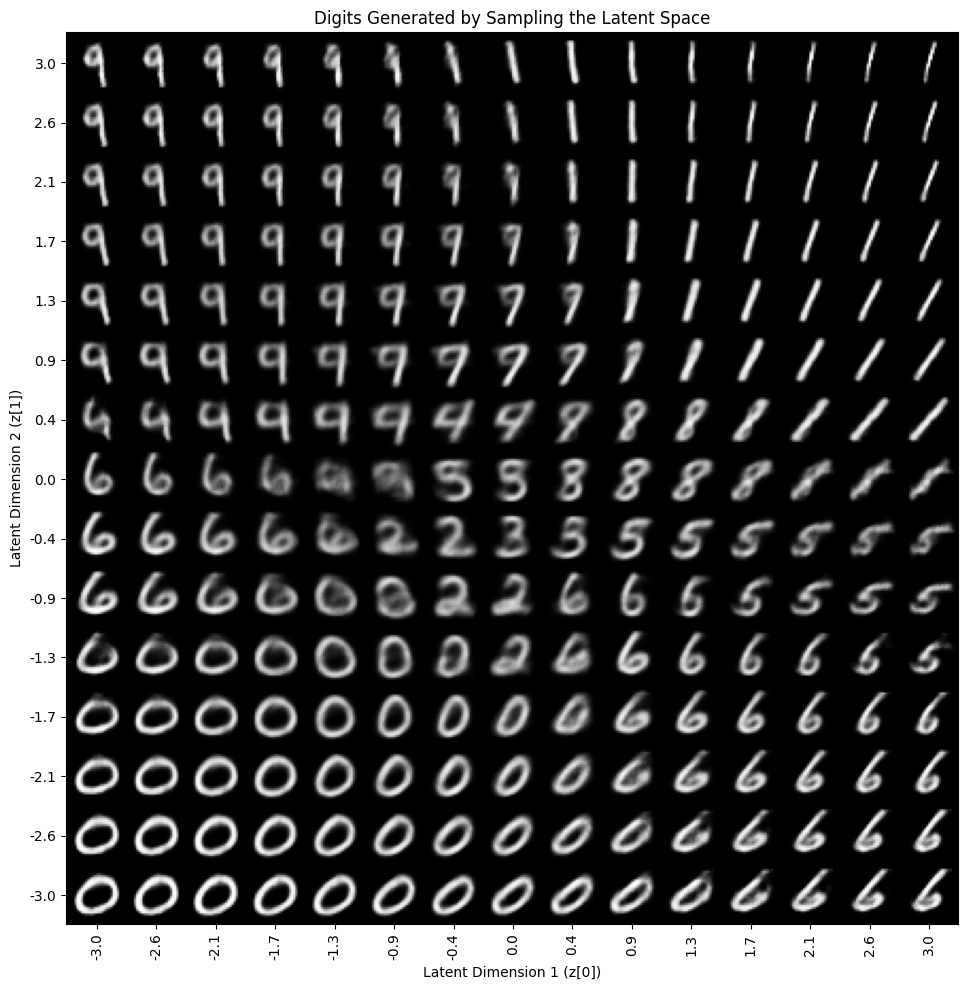

In [11]:
# ============================================================
# Figure 4: Digits Generated by Sampling the Latent Space
# ============================================================
n_grid = 15  # 15x15 grid of generated digits
digit_size = 28
grid_range = 3  # sample from -3 to +3 in each latent dimension

grid_x = np.linspace(-grid_range, grid_range, n_grid)
grid_y = np.linspace(-grid_range, grid_range, n_grid)[::-1]  # flip for natural plotting orientation

figure = np.zeros((digit_size * n_grid, digit_size * n_grid))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        decoded = decoder.predict(z_sample, verbose=0)
        digit = decoded.reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")

# Label axes with latent coordinate values
pixel_range_x = np.arange(digit_size // 2, n_grid * digit_size, digit_size)
pixel_range_y = np.arange(digit_size // 2, n_grid * digit_size, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range_x, sample_range_x, rotation=90)
plt.yticks(pixel_range_y, sample_range_y)
plt.xlabel("Latent Dimension 1 (z[0])")
plt.ylabel("Latent Dimension 2 (z[1])")
plt.title("Digits Generated by Sampling the Latent Space")
plt.tight_layout()
plt.show()


## 12. Observations

*(Fill in these answers after running the notebook and inspecting Figures 3 and 4. The points below describe the pattern that is typically observed for a correctly trained MNIST VAE — confirm/adjust based on your own actual output.)*

**1. Do similar digits form clusters?**
Yes — in the 2D latent scatter plot (Figure 3), test images belonging to the same digit label generally group into a visible, roughly contiguous region/cluster, since the encoder learns to place structurally similar handwritten digits close together.

**2. Are the clusters clearly separated?**
Digits with visually distinct shapes (e.g., 0 and 1) tend to form clusters that are fairly well separated, while digits that are written in visually similar ways (e.g., 4/9, 3/5/8) often show **overlapping boundaries** rather than hard separations. This is expected — with only 2 latent dimensions and no label information given to the encoder, the VAE cannot perfectly separate all 10 classes the way a supervised classifier would.

**3. How do the generated digits change when moving gradually through the latent space?**
Moving across the grid in Figure 4 from one region to a neighbouring region causes the generated digit to **morph gradually** — for example, a "1" might slowly curve and thicken into a "7", or a "3" might gradually reshape into an "8", passing through visually intermediate/ambiguous shapes along the way.

**4. Does the transition between generated images appear smooth?**
Yes — because the KL-divergence term regularizes the latent space to be continuous and densely packed (rather than having gaps), adjacent points in the grid decode to images that differ only slightly from their neighbours, producing a smooth, continuous visual transition across the grid rather than abrupt jumps.

---


## 13. Results

| Figure | Description |
|---|---|
| **Figure 1** | Sample MNIST Images — a set of 10 raw digit images (0–9) from the training set, shown before any processing by the VAE. |
| **Figure 2** | Reconstruction and KL-Divergence Loss vs Epoch — line graph tracking both loss components across all 20 training epochs. |
| **Figure 3** | 2D Latent Space Scatter Plot — all 10,000 test-set images plotted at their encoded `(z_mean[0], z_mean[1])` coordinates, coloured by true digit label. |
| **Figure 4** | Decoded Image Grid — a 15×15 grid of digit images generated by decoding evenly spaced latent coordinates in the range [−3, 3] × [−3, 3]. |

*(Figures 1–4 above are generated directly by the executable code cells in Sections 5, 9, 10, and 11 respectively when this notebook is run.)*

---
